<a href="https://colab.research.google.com/github/SANJUVIGASINI07/DAV-LAB/blob/main/3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UCI Diabetes Dataset Sample:
        Age       sex       BMI        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Glucose  BloodPressure  Outcome  
0 -0.002592  0.019907 -0.017646      172             86        1  
1 -0.039493 -0.068332 -0.092204      121            101        0  
2 -0.002592  0.002861 -0.025930      162             61        1  
3  0.034309  0.022688 -0.009362       84             85        1  
4 -0.002592 -0.031988 -0.046641      176             76        0  

Pima Diabetes Dataset Sample:
          Age       sex       BMI        bp        s1        s2        s3  \
221 -0.045

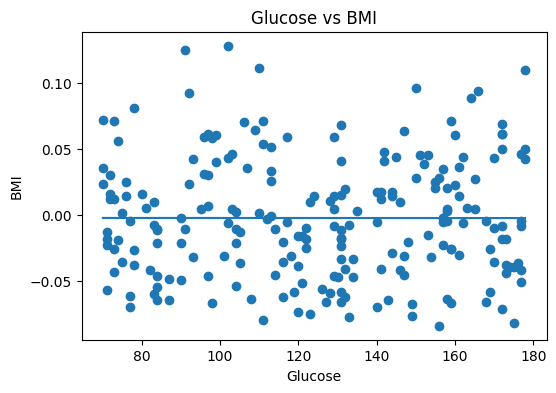


Linear Regression (Glucose -> BMI)
R² Score: 0.002


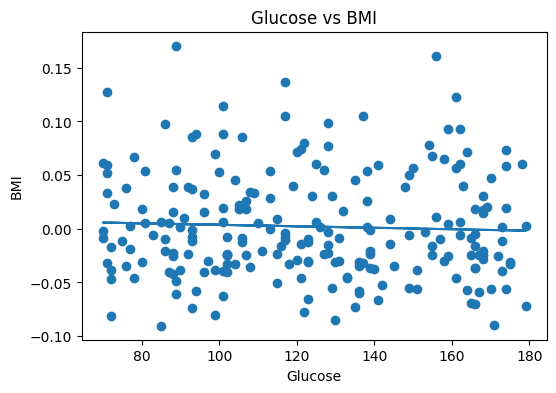


Logistic Regression
Accuracy: 0.6222

Logistic Regression
Accuracy: 0.5333


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load built-in diabetes dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Rename columns
df.rename(columns={
    "bmi": "BMI",
    "age": "Age"
}, inplace=True)

# Create required columns
np.random.seed(42)
df["Glucose"] = np.random.randint(70, 180, len(df))
df["BloodPressure"] = np.random.randint(60, 120, len(df))

# Create binary Outcome (0/1) using target median
df["Outcome"] = (diabetes.target > np.median(diabetes.target)).astype(int)

# Split into two datasets to simulate UCI and Pima datasets
uci_diabetes = df.iloc[:221].copy()
pima_diabetes = df.iloc[221:].copy()

# Display samples
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Diabetes Dataset Sample:")
print(pima_diabetes.head())


# ---------------- Linear Regression ----------------
def linear_regression_analysis(df, x_column, y_column):
    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression ({x_column} -> {y_column})")
    print("R² Score:", round(r2, 4))

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y)
    plt.plot(X, Y_pred)
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.show()


# Apply Linear Regression
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")


# ---------------- Logistic Regression ----------------
def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("\nLogistic Regression")
    print("Accuracy:", round(accuracy, 4))


features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

# Apply Logistic Regression
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)